### Importing Libraries

In [1]:
import os
import warnings
warnings.simplefilter('ignore')

In [2]:
import numpy as np
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
from skimage.io import imread, imshow
from skimage.transform import resize
from skimage.color import rgb2gray

### Path of Dataset

In [5]:
angry=os.listdir("C:\\Users\\Guhan.M\\Pictures\\angry")

In [6]:
sad=os.listdir("C:\\Users\\Guhan.M\\Pictures\\sad")

In [7]:
smile=os.listdir("C:\\Users\\Guhan.M\\Pictures\\smile")

### Reading Images

In [8]:
limit=29
angry_images=[None]*limit 
j=0
for i in angry:
    if(j<limit):
        angry_images[j]=imread("C:\\Users\\Guhan.M\\Pictures\\angry\\"+i)
        j+=1
    else:
        break

In [9]:
sad_images=[None]*limit
j=0
for i in sad:
    if(j<limit):
        sad_images[j]=imread("C:\\Users\\Guhan.M\\Pictures\\sad\\"+i)
        j+=1
    else:
        break

In [10]:
smile_images=[None]*limit
j=0
for i in smile:
    if(j<limit):
        smile_images[j]=imread("C:\\Users\\Guhan.M\\Pictures\\smile\\"+i)
        j+=1
    else:
        break

### View Dataset

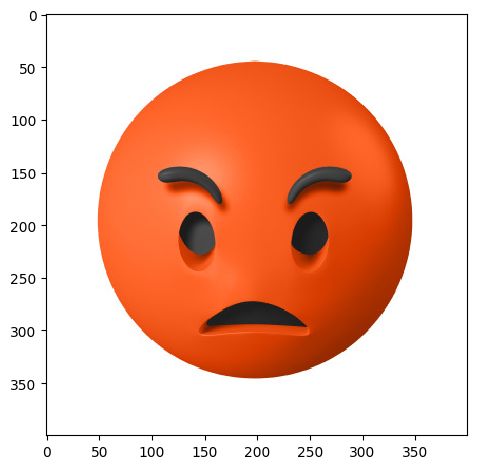

In [11]:
imshow(angry_images[19])
plt.show()

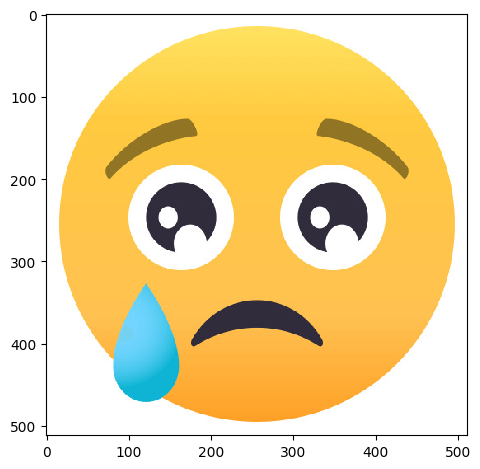

In [12]:
imshow(sad_images[6])
plt.show()

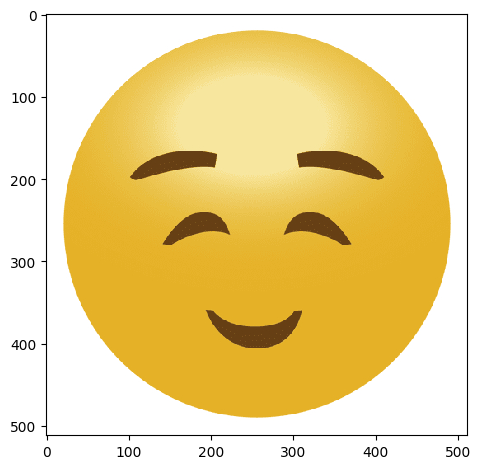

In [13]:
imshow(smile_images[23])
plt.show()

### Images to Gray Scale

In [14]:
angry_gray=[None]*limit
j=0
for i in angry:
    if(j<limit):
        angry_gray[j]=rgb2gray(angry_images[j][:,:,:3])
        j+=1
    else:
        break

In [15]:
sad_gray=[None]*limit
j=0
for i in sad:
    if(j<limit):
        sad_gray[j]=rgb2gray(sad_images[j])
        j+=1
    else:
        break

In [16]:
smile_gray=[None]*limit
j=0
for i in smile:
    if(j<limit):
        smile_gray[j]=rgb2gray(smile_images[j])
        j+=1
    else:
        break

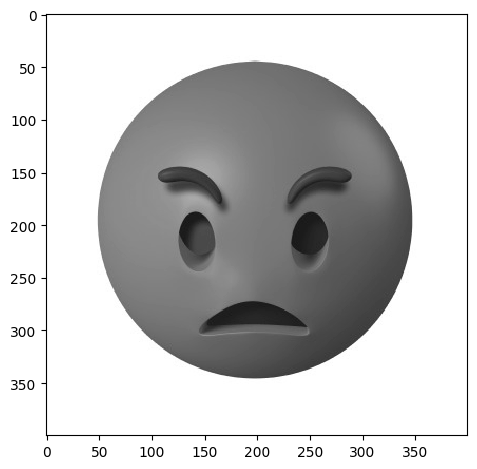

In [17]:
imshow(angry_gray[19])
plt.show()

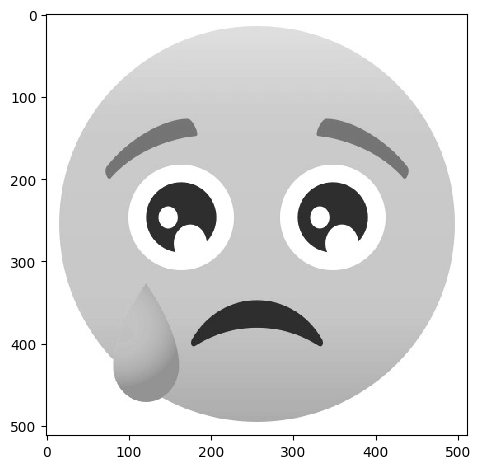

In [18]:
imshow(sad_gray[6])
plt.show()

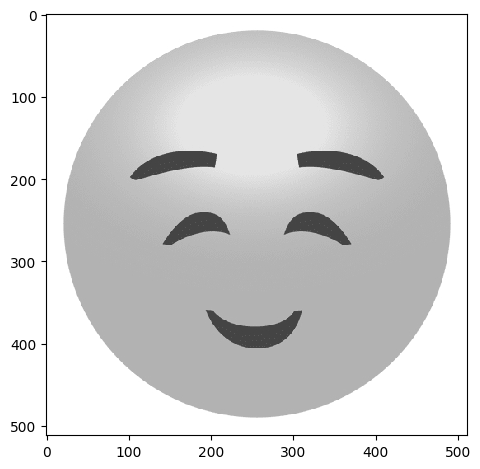

In [19]:
imshow(smile_gray[23])
plt.show()

### Resizing the Images

In [20]:
angry_gray[19].shape

(400, 400)

In [21]:
sad_gray[19].shape

(512, 512)

In [22]:
smile_gray[19].shape

(1280, 1280)

In [23]:
for j in range (29):
    ang=angry_gray[j]
    angry_gray[j]=resize(ang,(512,512))

In [24]:
for j in range (29):
    sa=sad_gray[j]
    sad_gray[j]=resize(sa,(512,512))

In [25]:
for j in range (29):
    smi=smile_gray[j]
    smile_gray[j]=resize(smi,(512,512))

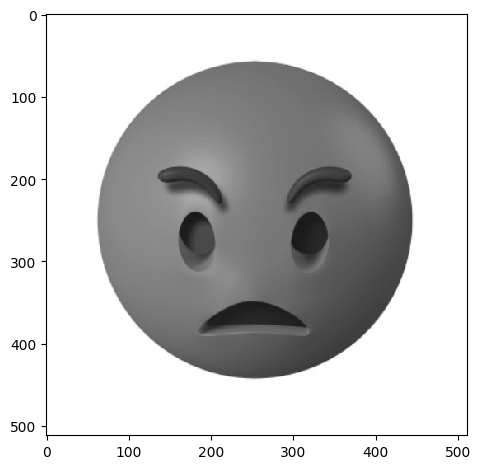

In [26]:
imshow(angry_gray[19])
plt.show()

In [27]:
angry_gray[19].shape

(512, 512)

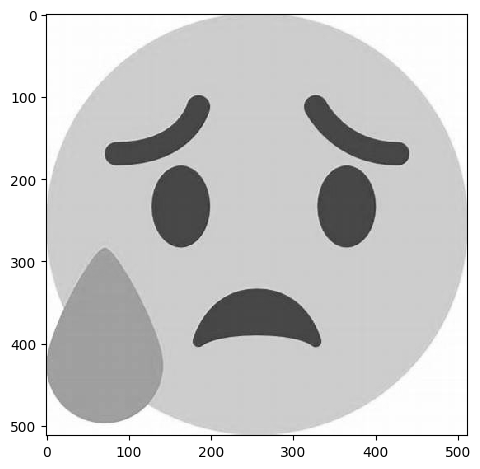

In [28]:
imshow(sad_gray[19])
plt.show()

In [29]:
sad_gray[19].shape

(512, 512)

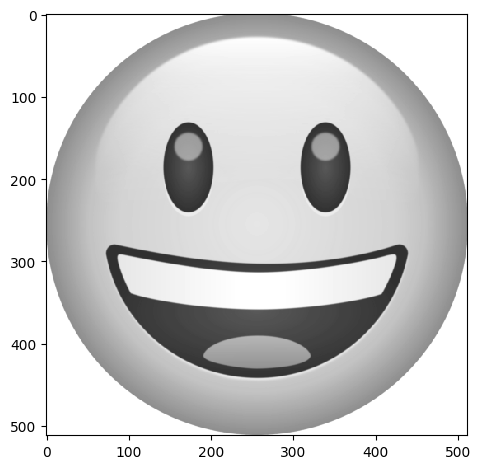

In [30]:
imshow(smile_gray[19])
plt.show()

In [31]:
smile_gray[19].shape

(512, 512)

### Vector Conversion

#### For Angry Emoji

In [32]:
len_of_images_angry=len(angry_gray)

In [33]:
len_of_images_angry

29

In [34]:
image_size_angry=angry_gray[1].shape

In [35]:
image_size_angry

(512, 512)

In [36]:
flatten_size_angry=image_size_angry[0]*image_size_angry[1]

In [37]:
flatten_size_angry

262144

In [38]:
for i in range(len_of_images_angry):
    angry_gray[i]=np.ndarray.flatten(angry_gray[i]).reshape(flatten_size_angry,1)

In [39]:
angry_gray=np.dstack(angry_gray)

In [40]:
angry_gray

array([[[1., 1., 1., ..., 1., 1., 1.]],

       [[1., 1., 1., ..., 1., 1., 1.]],

       [[1., 1., 1., ..., 1., 1., 1.]],

       ...,

       [[1., 1., 1., ..., 1., 1., 1.]],

       [[1., 1., 1., ..., 1., 1., 1.]],

       [[1., 1., 1., ..., 1., 1., 1.]]])

In [41]:
angry_gray.shape

(262144, 1, 29)

In [42]:
angry_gray=np.rollaxis(angry_gray,axis=2,start=0)

In [43]:
angry_gray.shape

(29, 262144, 1)

In [44]:
angry_gray=angry_gray.reshape(len_of_images_angry,flatten_size_angry)

In [45]:
angry_gray.shape

(29, 262144)

In [46]:
angry_data=pd.DataFrame(angry_gray)

In [47]:
angry_data

,0,1,2,3,4,5,6,7,8,9,...,262134,262135,262136,262137,262138,262139,262140,262141,262142,262143
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.253191,0.253191,0.253191,0.253191,0.253191,0.253191,0.253191,0.253191,0.253191,0.253191
7,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
9,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,...,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536


In [48]:
angry_data["label"]="angry"

In [49]:
angry_data

,0,1,2,3,4,5,6,7,8,9,...,262135,262136,262137,262138,262139,262140,262141,262142,262143,label
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,angry
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,angry
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,angry
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,angry
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,angry
5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,angry
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.253191,0.253191,0.253191,0.253191,0.253191,0.253191,0.253191,0.253191,0.253191,angry
7,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,angry
8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,angry
9,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,...,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,0.265536,angry


#### For Sad Emoji

In [50]:
len_of_images_sad=len(sad_gray)

In [51]:
len_of_images_sad

29

In [52]:
image_size_sad=sad_gray[1].shape

In [53]:
image_size_sad

(512, 512)

In [54]:
flatten_size_sad=image_size_sad[0]*image_size_sad[1]

In [55]:
flatten_size_sad

262144

In [56]:
for i in range(len_of_images_sad):
    sad_gray[i]=np.ndarray.flatten(sad_gray[i]).reshape(flatten_size_sad,1)

In [57]:
sad_gray=np.dstack(sad_gray)

In [58]:
sad_gray

array([[[1.        , 1.        , 0.94117647, ..., 1.        ,
         1.        , 1.        ]],

       [[1.        , 1.        , 0.94117647, ..., 1.        ,
         1.        , 1.        ]],

       [[1.        , 1.        , 0.94117647, ..., 1.        ,
         1.        , 1.        ]],

       ...,

       [[1.        , 1.        , 0.94117647, ..., 1.        ,
         1.        , 1.        ]],

       [[1.        , 1.        , 0.94117647, ..., 1.        ,
         1.        , 1.        ]],

       [[1.        , 1.        , 0.94117647, ..., 1.        ,
         1.        , 1.        ]]])

In [59]:
sad_gray.shape

(262144, 1, 29)

In [60]:
sad_gray=np.rollaxis(sad_gray,axis=2,start=0)

In [61]:
sad_gray.shape

(29, 262144, 1)

In [62]:
sad_gray=sad_gray.reshape(len_of_images_sad,flatten_size_sad)

In [63]:
sad_gray.shape

(29, 262144)

In [64]:
sad_data=pd.DataFrame(sad_gray)

In [65]:
sad_data

,0,1,2,3,4,5,6,7,8,9,...,262134,262135,262136,262137,262138,262139,262140,262141,262142,262143
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,...,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
9,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [66]:
sad_data["label"]="sad"
sad_data

,0,1,2,3,4,5,6,7,8,9,...,262135,262136,262137,262138,262139,262140,262141,262142,262143,label
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sad
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sad
2,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,...,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,sad
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sad
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sad
5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sad
6,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sad
7,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sad
8,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sad
9,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sad


#### For Smile

In [67]:
len_of_images_smile=len(smile_gray)
len_of_images_smile

29

In [68]:
image_size_smile=smile_gray[1].shape

In [69]:
image_size_smile

(512, 512)

In [70]:
flatten_size_smile=image_size_smile[0]*image_size_smile[1]
flatten_size_smile

262144

In [71]:
for i in range(len_of_images_smile):
    smile_gray[i]=np.ndarray.flatten(smile_gray[i]).reshape(flatten_size_smile,1)

In [72]:
smile_gray=np.dstack(smile_gray)
smile_gray

array([[[1., 1., 1., ..., 1., 1., 1.]],

       [[1., 1., 1., ..., 1., 1., 1.]],

       [[1., 1., 1., ..., 1., 1., 1.]],

       ...,

       [[1., 1., 1., ..., 1., 1., 1.]],

       [[1., 1., 1., ..., 1., 1., 1.]],

       [[1., 1., 1., ..., 1., 1., 1.]]])

In [73]:
smile_gray.shape

(262144, 1, 29)

In [74]:
smile_gray=np.rollaxis(smile_gray,axis=2,start=0)
smile_gray.shape

(29, 262144, 1)

In [75]:
smile_gray=smile_gray.reshape(len_of_images_smile,flatten_size_smile)
smile_gray.shape

(29, 262144)

In [76]:
smile_data=pd.DataFrame(smile_gray)
smile_data

,0,1,2,3,4,5,6,7,8,9,...,262134,262135,262136,262137,262138,262139,262140,262141,262142,262143
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
6,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,...,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974
7,0.945568,0.962975,0.967257,0.967996,0.958881,0.962252,0.965049,0.962831,0.962547,0.971906,...,0.959711,0.958756,0.949794,0.953400,0.955499,0.953127,0.946889,0.951424,0.944717,0.927850
8,0.959757,0.970078,0.968578,0.967577,0.962142,0.963784,0.965773,0.965054,0.967103,0.969697,...,0.946088,0.944689,0.942406,0.943080,0.943080,0.941790,0.940726,0.944818,0.931683,0.938138
9,0.948510,0.964276,0.969404,0.964223,0.961667,0.961176,0.962119,0.965135,0.968544,0.968850,...,0.957739,0.956945,0.949767,0.953400,0.955499,0.952549,0.946690,0.960675,0.941900,0.936509


In [77]:
smile_data["label"]="smile"
smile_data

,0,1,2,3,4,5,6,7,8,9,...,262135,262136,262137,262138,262139,262140,262141,262142,262143,label
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,smile
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,smile
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,smile
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,smile
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,smile
5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,smile
6,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,...,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,0.964974,smile
7,0.945568,0.962975,0.967257,0.967996,0.958881,0.962252,0.965049,0.962831,0.962547,0.971906,...,0.958756,0.949794,0.953400,0.955499,0.953127,0.946889,0.951424,0.944717,0.927850,smile
8,0.959757,0.970078,0.968578,0.967577,0.962142,0.963784,0.965773,0.965054,0.967103,0.969697,...,0.944689,0.942406,0.943080,0.943080,0.941790,0.940726,0.944818,0.931683,0.938138,smile
9,0.948510,0.964276,0.969404,0.964223,0.961667,0.961176,0.962119,0.965135,0.968544,0.968850,...,0.956945,0.949767,0.953400,0.955499,0.952549,0.946690,0.960675,0.941900,0.936509,smile


### Combines All Dataset

In [78]:
emoji=pd.concat([angry_data,sad_data,smile_data])
emoji

,0,1,2,3,4,5,6,7,8,9,...,262135,262136,262137,262138,262139,262140,262141,262142,262143,label
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,angry
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,angry
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,angry
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,angry
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,angry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,smile
25,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,smile
26,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,smile
27,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,smile


In [79]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [80]:
from sklearn.utils import shuffle
emoji_indexed=shuffle(emoji).reset_index()
emoji_indexed

,index,0,1,2,3,4,5,6,7,8,...,262135,262136,262137,262138,262139,262140,262141,262142,262143,label
0,15,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,...,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,sad
1,24,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sad
2,13,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,smile
3,17,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,smile
4,28,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,angry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,17,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,angry
83,2,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,...,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,sad
84,27,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,smile
85,26,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,angry


In [81]:
emoji_types=emoji_indexed.drop(['index'],axis=1)
emoji_types

,0,1,2,3,4,5,6,7,8,9,...,262135,262136,262137,262138,262139,262140,262141,262142,262143,label
0,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,...,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,sad
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sad
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,smile
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,smile
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,angry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,angry
83,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,...,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,0.941176,sad
84,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,smile
85,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,angry


In [82]:
emoji_types.to_csv("emoji.csv")

### Training and Testing Set

In [83]:
x=emoji_types.values[:,:-1]
y=emoji_types.values[:,-1]

In [84]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)
x_train.shape

(65, 262144)

In [85]:
x_test.shape

(22, 262144)

#### PCA

In [86]:
from sklearn import decomposition
pca = decomposition.PCA(n_components=20, whiten=True, random_state=1)

In [87]:
pca.fit(x_train)

PCA(n_components=20, random_state=1, whiten=True)

In [88]:
x_train_pca = pca.transform(x_train)
x_test_pca = pca.transform(x_test)

In [89]:
x_train_pca.shape

(65, 20)

In [90]:
x_test_pca.shape

(22, 20)

### Egien Faces

In [91]:
eigen = (np.reshape(x[29],(512,512)).astype(np.float64))
eigen

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

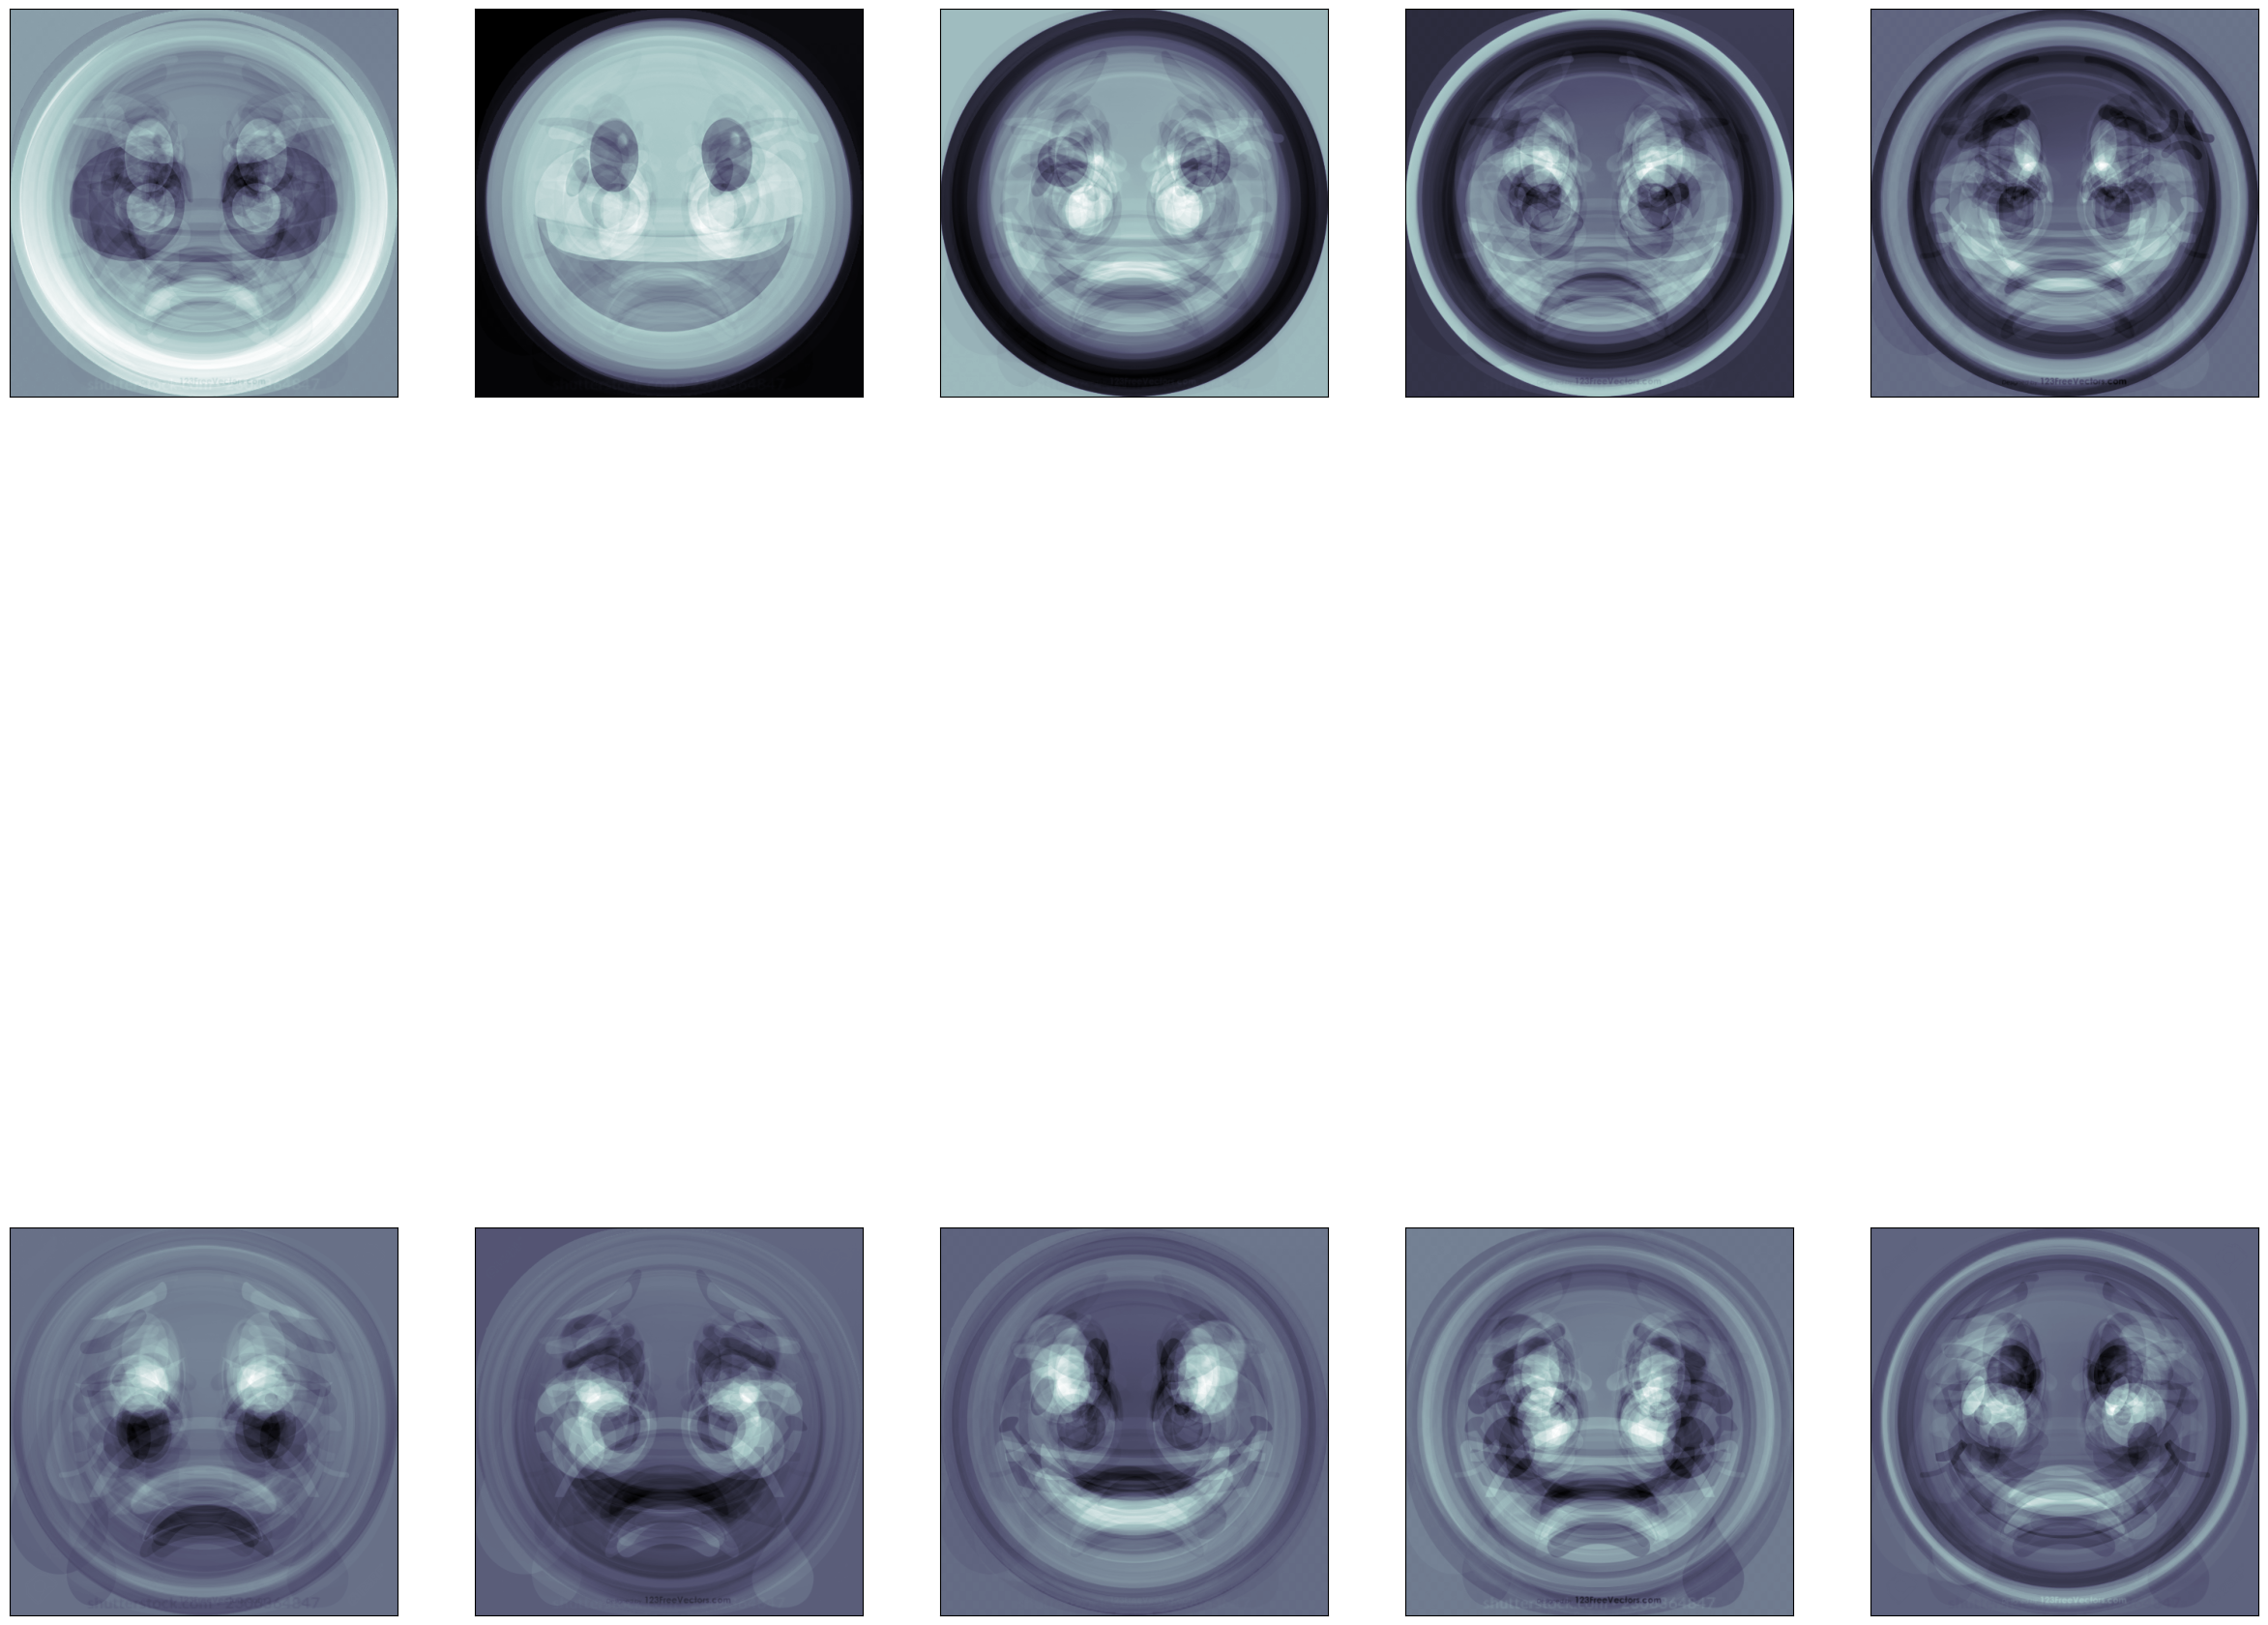

In [92]:
fig = plt.figure(figsize=(30,30))
for i in range(10):
    ax = fig.add_subplot(2, 5, i+1, xticks=[], yticks=[])
    ax.imshow(pca.components_[i].reshape(eigen.shape), cmap=plt.cm.bone)
plt.show()

### Random Forest

In [93]:
from sklearn.ensemble import RandomForestClassifier

In [94]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train_pca,y_train)

RandomForestClassifier(random_state=42)

#### Prediction

In [95]:
y_pred=clf.predict(x_test_pca)
y_pred

array(['smile', 'angry', 'angry', 'sad', 'angry', 'angry', 'smile', 'sad',
       'angry', 'sad', 'angry', 'smile', 'sad', 'sad', 'angry', 'sad',
       'smile', 'smile', 'smile', 'smile', 'smile', 'sad'], dtype=object)

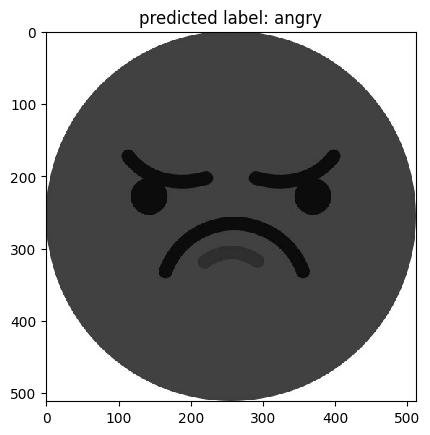

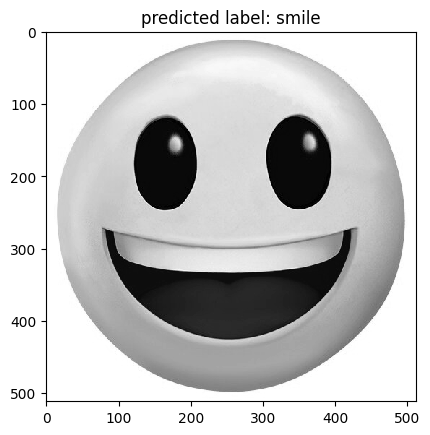

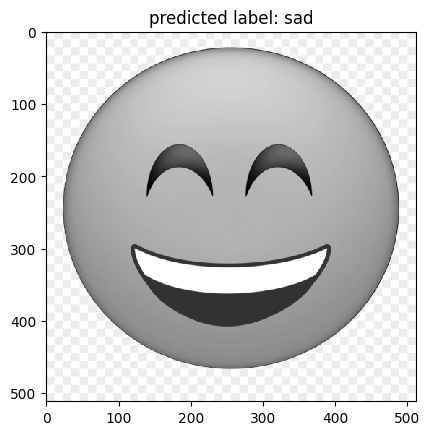

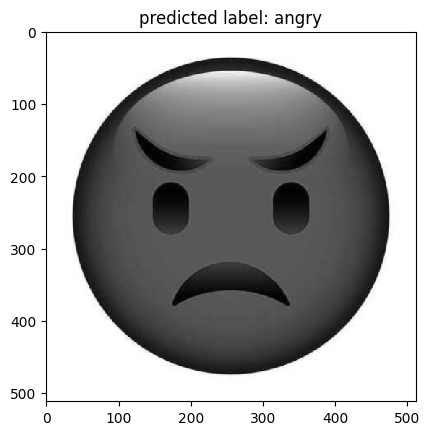

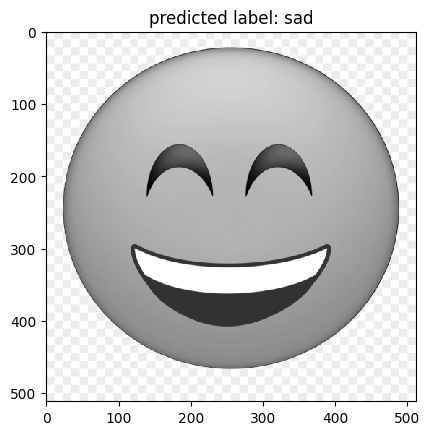

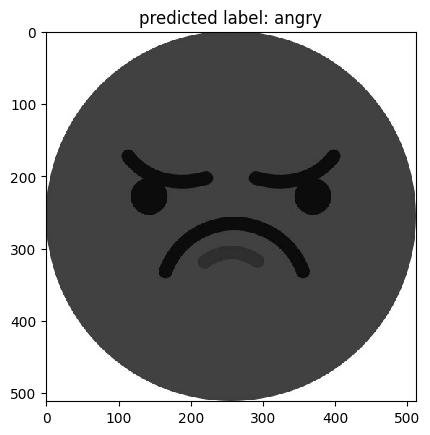

In [96]:
for i in (np.random.randint(0,6,6)):
    predicted_images = (np.reshape(x_test[i], (512,512)).astype(np.float64))
    plt.title('predicted label: {0}'. format(y_pred[i]))
    plt.imshow(predicted_images, interpolation='nearest', cmap='gray')
    plt.show()

#### Accuracy

In [97]:
from sklearn import metrics

In [98]:
accuracy=metrics.accuracy_score(y_test,y_pred)
accuracy

0.9090909090909091

#### Error Analysis

In [99]:
from sklearn.metrics import confusion_matrix

In [100]:
confusion_matrix(y_test,y_pred)

array([[7, 0, 0],
       [0, 6, 1],
       [0, 1, 7]])

#### Classification Report

In [101]:
from sklearn.metrics import classification_report

In [102]:
 print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       angry       1.00      1.00      1.00         7
         sad       0.86      0.86      0.86         7
       smile       0.88      0.88      0.88         8

    accuracy                           0.91        22
   macro avg       0.91      0.91      0.91        22
weighted avg       0.91      0.91      0.91        22

